<div style='color: #216969;
           background-color: #EAF6F6;
           font-size: 200%;
           border-radius:15px;
           text-align:center;
           font-weight:600;
           border-style: solid;
           border-color: dark green;
           font-family: "Cambria";'>
Pipeline
<a class="anchor" id="1"></a> 

In [ ]:
# dataset loading 
import pandas as pd
import numpy as np
df = pd.read_csv('../data/Students_Grading_Dataset.csv')

![](../../imgs/featureEngin.png)

In [141]:
df.head()

,Student_ID,First_Name,Last_Name,Email,Gender,Age,Department,Attendance (%),Midterm_Score,Final_Score,...,Projects_Score,Total_Score,Grade,Study_Hours_per_Week,Extracurricular_Activities,Internet_Access_at_Home,Parent_Education_Level,Family_Income_Level,Stress_Level (1-10),Sleep_Hours_per_Night
0,S1000,Omar,Williams,student0@university.com,Female,22,Engineering,52.29,55.03,57.82,...,85.90,56.09,F,6.2,No,Yes,High School,Medium,5,4.7
1,S1001,Maria,Brown,student1@university.com,Male,18,Engineering,97.27,97.23,45.80,...,55.65,50.64,A,19.0,No,Yes,NaN,Medium,4,9.0
2,S1002,Ahmed,Jones,student2@university.com,Male,24,Business,57.19,67.05,93.68,...,73.79,70.30,D,20.7,No,Yes,Master's,Low,6,6.2
3,S1003,Omar,Williams,student3@university.com,Female,24,Mathematics,95.15,47.79,80.63,...,92.12,61.63,A,24.8,Yes,Yes,High School,High,3,6.7
4,S1004,John,Smith,student4@university.com,Female,23,CS,54.18,46.59,78.89,...,68.42,66.13,F,15.4,Yes,Yes,High School,High,2,7.1


![](../imgs/featureEngin.png)

In [142]:
# missing values 
df.isnull().sum()/df.shape[0]

Student_ID                    0.0000
First_Name                    0.0000
Last_Name                     0.0000
Email                         0.0000
Gender                        0.0000
Age                           0.0000
Department                    0.0000
Attendance (%)                0.1032
Midterm_Score                 0.0000
Final_Score                   0.0000
Assignments_Avg               0.1034
Quizzes_Avg                   0.0000
Participation_Score           0.0000
Projects_Score                0.0000
Total_Score                   0.0000
Grade                         0.0000
Study_Hours_per_Week          0.0000
Extracurricular_Activities    0.0000
Internet_Access_at_Home       0.0000
Parent_Education_Level        0.3588
Family_Income_Level           0.0000
Stress_Level (1-10)           0.0000
Sleep_Hours_per_Night         0.0000
dtype: float64

In [143]:
df.Final_Score.describe()

count    5000.000000
mean       69.640788
std        17.238744
min        40.000000
25%        54.667500
50%        69.735000
75%        84.500000
max        99.980000
Name: Final_Score, dtype: float64

In [144]:
df.dtypes

Student_ID                     object
First_Name                     object
Last_Name                      object
Email                          object
Gender                         object
Age                             int64
Department                     object
Attendance (%)                float64
Midterm_Score                 float64
Final_Score                   float64
Assignments_Avg               float64
Quizzes_Avg                   float64
Participation_Score           float64
Projects_Score                float64
Total_Score                   float64
Grade                          object
Study_Hours_per_Week          float64
Extracurricular_Activities     object
Internet_Access_at_Home        object
Parent_Education_Level         object
Family_Income_Level            object
Stress_Level (1-10)             int64
Sleep_Hours_per_Night         float64
dtype: object

## Part I .  Numerical features only

In [145]:
# transform retained columns object to category 
cat_features = df.select_dtypes("object").columns
df[cat_features]= df[cat_features].astype("category")

In [147]:
df.dtypes

Student_ID                    category
First_Name                    category
Last_Name                     category
Email                         category
Gender                        category
Age                              int64
Department                    category
Attendance (%)                 float64
Midterm_Score                  float64
Final_Score                    float64
Assignments_Avg                float64
Quizzes_Avg                    float64
Participation_Score            float64
Projects_Score                 float64
Total_Score                    float64
Grade                         category
Study_Hours_per_Week           float64
Extracurricular_Activities    category
Internet_Access_at_Home       category
Parent_Education_Level        category
Family_Income_Level           category
Stress_Level (1-10)              int64
Sleep_Hours_per_Night          float64
dtype: object

In [148]:
df["Attendance (%)"].describe().T

count    4484.000000
mean       75.431409
std        14.372446
min        50.010000
25%        63.265000
50%        75.725000
75%        87.472500
max       100.000000
Name: Attendance (%), dtype: float64

In [149]:
df["results"] = np.where(df["Final_Score"] > 50, 1, 0)

In [150]:
df.results.value_counts()

results
1    4152
0     848
Name: count, dtype: int64

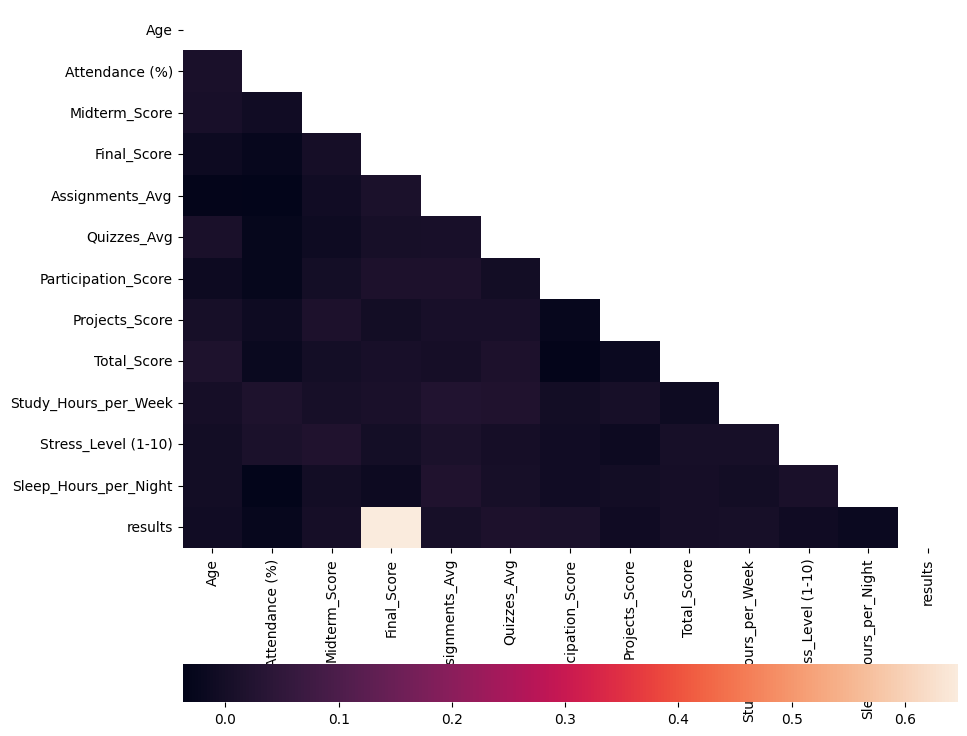

In [151]:
# مصفوفة الارتباطات
import seaborn as sns
import matplotlib.pyplot as plt
num_features=df.select_dtypes(include=[np.number]).columns
plt.figure(figsize=(10,10))
df_cor=df[num_features].corr()

matrix=np.triu(df_cor)
_=sns.heatmap(df_cor, mask=matrix,  cbar_kws={"orientation": "horizontal"})

![](../imgs/target.jpeg)

In [152]:
X= df.select_dtypes("number").drop(["Final_Score", "results"], axis=1)
y= df["results"]

In [153]:
X.head()

,Age,Attendance (%),Midterm_Score,Assignments_Avg,Quizzes_Avg,Participation_Score,Projects_Score,Total_Score,Study_Hours_per_Week,Stress_Level (1-10),Sleep_Hours_per_Night
0,22,52.29,55.03,84.22,74.06,3.99,85.90,56.09,6.2,5,4.7
1,18,97.27,97.23,NaN,94.24,8.32,55.65,50.64,19.0,4,9.0
2,24,57.19,67.05,67.70,85.70,5.05,73.79,70.30,20.7,6,6.2
3,24,95.15,47.79,66.06,93.51,6.54,92.12,61.63,24.8,3,6.7
4,23,54.18,46.59,96.85,83.70,5.97,68.42,66.13,15.4,2,7.1


![](../imgs/dataSplit.jpg)

In [154]:
#. split the data into training and testing sets
from sklearn.model_selection import train_test_split    
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y,   random_state=42)

In [155]:
#   value counts fro an y_train 
y_test.value_counts()


results
1    1246
0     254
Name: count, dtype: int64

In [ ]:
# impute missing values
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy="mean")
# X_train_imputed = imputer.fit_transform(X_train)
# X_test_imputed = imputer.transform(X_test)

![](../../imgs/model.png)

In [157]:
# logistic regression model 
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()


<img src="../../imgs/pipeline.jpg" alt="Pipeline" width="300">

In [158]:
# create pipeline  to impute missing data , standarscaler and model
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
pipe = make_pipeline(imputer, StandardScaler(), model)

In [159]:
# fit the model
pipe.fit(X_train, y_train)


Pipeline(steps=[('simpleimputer', SimpleImputer()),
                ('standardscaler', StandardScaler()),
                ('logisticregression', LogisticRegression())])

In [160]:
# pipeline score 
pipe.score(X_test, y_test)

0.8306666666666667

In [161]:
# siapay name steps 
pipe.named_steps

{'simpleimputer': SimpleImputer(),
 'standardscaler': StandardScaler(),
 'logisticregression': LogisticRegression()}

In [162]:
pipe.named_steps.simpleimputer.statistics_  # to get the mean of the imputer

array([21.06914286, 75.52754057, 70.39825714, 74.9633535 , 75.17442571,
        4.95693714, 74.90300857, 75.03613429, 17.56065714,  5.49      ,
        6.49328571])

In [163]:
# get the coefficients of the model
model.coef_

array([[ 0.00149421, -0.0884851 , -0.0304041 , -0.00365003,  0.0138787 ,
         0.06556614, -0.042213  , -0.02417094,  0.04778739, -0.05734199,
        -0.02270502]])

In [164]:
# same as above model.coef_
pipe.named_steps.logisticregression.coef_

array([[ 0.00149421, -0.0884851 , -0.0304041 , -0.00365003,  0.0138787 ,
         0.06556614, -0.042213  , -0.02417094,  0.04778739, -0.05734199,
        -0.02270502]])

In [165]:
# display a confusion matrix of the model 
from sklearn.metrics import confusion_matrix
y_pred = pipe.predict(X_test)
confusion_matrix(y_test, y_pred)

array([[   0,  254],
       [   0, 1246]])

Text(50.722222222222214, 0.5, 'Actual')

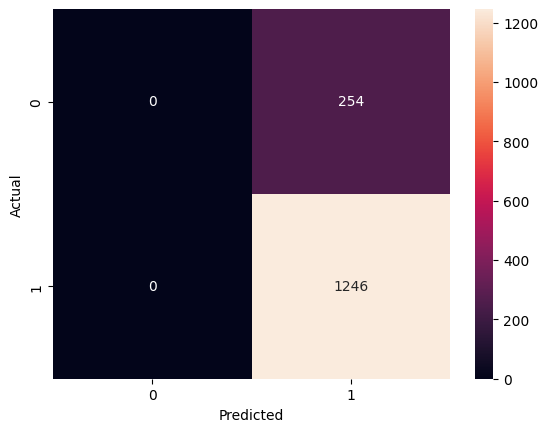

In [166]:
# use seabon to display the confusion matrix
import seaborn as sns
import matplotlib.pyplot as plt
_=sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')

![](../../imgs/metrics.png)

In [167]:
# use skalern to get the classification report
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred, zero_division=True))



              precision    recall  f1-score   support

           0       1.00      0.00      0.00       254
           1       0.83      1.00      0.91      1246

    accuracy                           0.83      1500
   macro avg       0.92      0.50      0.45      1500
weighted avg       0.86      0.83      0.75      1500



In [168]:
# get the probability of the model
y_pred_proba = pipe.predict_proba(X_test)
y_pred_proba[:5]

array([[0.1624392 , 0.8375608 ],
       [0.22042656, 0.77957344],
       [0.2020752 , 0.7979248 ],
       [0.19442307, 0.80557693],
       [0.15713334, 0.84286666]])

In [169]:
# display daframe of y_test vs y_pred and y_pred_proba

df_pred = pd.DataFrame({"y_test": y_test,"y_pres": y_pred ,  "y_pred_proba": y_pred_proba[:,1]})
df_pred.head()

,y_test,y_pres,y_pred_proba
1504,0,1,0.837561
330,1,1,0.779573
4307,1,1,0.797925
2413,1,1,0.805577
1521,1,1,0.842867


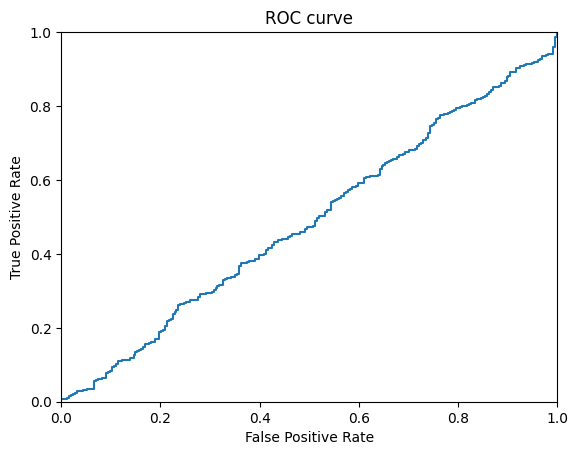

In [170]:
# display the roc curve
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba[:,1])
plt.plot(fpr, tpr)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC curve')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.show()


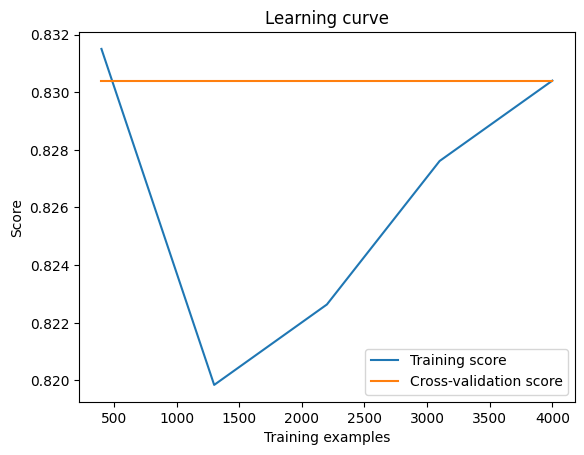

In [171]:
#  display learning curve
from sklearn.model_selection import learning_curve
train_sizes, train_scores, test_scores = learning_curve(pipe, X, y, cv=5)
train_sizes
train_scores_mean = train_scores.mean(axis=1)
test_scores_mean = test_scores.mean(axis=1)
plt.plot(train_sizes, train_scores_mean, label='Training score')
plt.plot(train_sizes, test_scores_mean, label='Cross-validation score')
plt.title('Learning curve')
plt.xlabel('Training examples')
plt.ylabel('Score')
plt.legend()
plt.show()

## Part II .  All features 

In [172]:
df.sample(5)

,Student_ID,First_Name,Last_Name,Email,Gender,Age,Department,Attendance (%),Midterm_Score,Final_Score,...,Total_Score,Grade,Study_Hours_per_Week,Extracurricular_Activities,Internet_Access_at_Home,Parent_Education_Level,Family_Income_Level,Stress_Level (1-10),Sleep_Hours_per_Night,results
2099,S3099,John,Brown,student2099@university.com,Female,19,Engineering,61.95,81.38,43.87,...,65.17,F,28.0,No,Yes,NaN,Low,1,7.5,0
4479,S5479,Emma,Smith,student4479@university.com,Male,23,CS,95.31,71.96,51.98,...,83.86,B,27.2,No,Yes,NaN,Medium,6,7.9,1
3639,S4639,Omar,Smith,student3639@university.com,Female,24,Engineering,99.73,84.55,53.96,...,52.84,A,13.7,No,Yes,NaN,High,10,6.7,1
3201,S4201,Ali,Williams,student3201@university.com,Female,20,Business,72.85,54.64,92.45,...,79.85,F,29.6,Yes,Yes,NaN,Medium,6,5.2,1
810,S1810,John,Davis,student810@university.com,Female,21,Business,74.18,96.56,46.39,...,53.97,D,22.3,No,Yes,Bachelor's,High,10,7.9,0


![](../../imgs/featureEngin.png)

In [173]:
for col in df.columns:
    if df[col].nunique()<8:
        print(f" {col :-<20} {df[col].nunique():_<10} {df[col].unique()}")

 Last_Name----------- 6_________ ['Williams', 'Brown', 'Jones', 'Smith', 'Davis', 'Johnson']
Categories (6, object): ['Brown', 'Davis', 'Johnson', 'Jones', 'Smith', 'Williams']
 Gender-------------- 2_________ ['Female', 'Male']
Categories (2, object): ['Female', 'Male']
 Age----------------- 7_________ [22 18 24 23 21 19 20]
 Department---------- 4_________ ['Engineering', 'Business', 'Mathematics', 'CS']
Categories (4, object): ['Business', 'CS', 'Engineering', 'Mathematics']
 Grade--------------- 5_________ ['F', 'A', 'D', 'B', 'C']
Categories (5, object): ['A', 'B', 'C', 'D', 'F']
 Extracurricular_Activities 2_________ ['No', 'Yes']
Categories (2, object): ['No', 'Yes']
 Internet_Access_at_Home 2_________ ['Yes', 'No']
Categories (2, object): ['No', 'Yes']
 Parent_Education_Level 4_________ ['High School', NaN, 'Master's', 'PhD', 'Bachelor's']
Categories (4, object): ['Bachelor's', 'High School', 'Master's', 'PhD']
 Family_Income_Level- 3_________ ['Medium', 'Low', 'High']
Categori

In [174]:
df.keys()

Index(['Student_ID', 'First_Name', 'Last_Name', 'Email', 'Gender', 'Age',
       'Department', 'Attendance (%)', 'Midterm_Score', 'Final_Score',
       'Assignments_Avg', 'Quizzes_Avg', 'Participation_Score',
       'Projects_Score', 'Total_Score', 'Grade', 'Study_Hours_per_Week',
       'Extracurricular_Activities', 'Internet_Access_at_Home',
       'Parent_Education_Level', 'Family_Income_Level', 'Stress_Level (1-10)',
       'Sleep_Hours_per_Night', 'results'],
      dtype='object')

In [175]:
features_toDrop= ["Student_ID", "First_Name", "Last_Name", "Email"]

In [176]:
df[features_toDrop].head()

,Student_ID,First_Name,Last_Name,Email
0,S1000,Omar,Williams,student0@university.com
1,S1001,Maria,Brown,student1@university.com
2,S1002,Ahmed,Jones,student2@university.com
3,S1003,Omar,Williams,student3@university.com
4,S1004,John,Smith,student4@university.com


In [178]:
# display objects no included in teh list of features to drop
df.drop(features_toDrop, axis=1, inplace=True)

In [179]:
df.head()


,Gender,Age,Department,Attendance (%),Midterm_Score,Final_Score,Assignments_Avg,Quizzes_Avg,Participation_Score,Projects_Score,Total_Score,Grade,Study_Hours_per_Week,Extracurricular_Activities,Internet_Access_at_Home,Parent_Education_Level,Family_Income_Level,Stress_Level (1-10),Sleep_Hours_per_Night,results
0,Female,22,Engineering,52.29,55.03,57.82,84.22,74.06,3.99,85.90,56.09,F,6.2,No,Yes,High School,Medium,5,4.7,1
1,Male,18,Engineering,97.27,97.23,45.80,NaN,94.24,8.32,55.65,50.64,A,19.0,No,Yes,NaN,Medium,4,9.0,0
2,Male,24,Business,57.19,67.05,93.68,67.70,85.70,5.05,73.79,70.30,D,20.7,No,Yes,Master's,Low,6,6.2,1
3,Female,24,Mathematics,95.15,47.79,80.63,66.06,93.51,6.54,92.12,61.63,A,24.8,Yes,Yes,High School,High,3,6.7,1
4,Female,23,CS,54.18,46.59,78.89,96.85,83.70,5.97,68.42,66.13,F,15.4,Yes,Yes,High School,High,2,7.1,1


![](../../imgs/target.jpeg)

In [182]:
X= df.drop(["Final_Score", "results"], axis=1)
y= df["results"]

![](../../imgs/datSplit.jpg)

In [233]:
#. split the data into training and testing sets
from sklearn.model_selection import train_test_split    
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y,   random_state=42)

<img src="../../imgs/pipeline.jpg" alt="Pipeline" width="500">

In [235]:
from sklearn.preprocessing import StandardScaler , OneHotEncoder
from sklearn.compose import make_column_transformer , make_column_selector  as selector
# from sklearn.compose import

from sklearn.pipeline import make_pipeline


num_pipeline= make_pipeline(
    SimpleImputer(strategy="mean"),  # imputing the data
     StandardScaler() ,   # scaling the data
     
)

cat_pipeline= make_pipeline(
     SimpleImputer(strategy="most_frequent"),  # imputing the data
      OneHotEncoder(drop="if_binary", sparse_output=False, handle_unknown="ignore")  # Ignore unknown categories
)

preprocess= make_column_transformer(
     ( num_pipeline,  selector(dtype_include="number") ),   # numeric

     (cat_pipeline, selector(dtype_exclude="number")) , #category 
     remainder="drop",
     n_jobs=-1
     )

In [236]:
preprocess.fit_transform(X_train).shape 

(4000, 30)

In [237]:
preprocess.fit_transform(X_train)

array([[ 0.97123127, -0.6681495 , -0.87745355, ...,  1.        ,
         0.        ,  0.        ],
       [ 1.4745251 , -0.61543028,  0.42153929, ...,  0.        ,
         1.        ,  0.        ],
       [-0.53865022,  1.64270959,  1.21127119, ...,  0.        ,
         0.        ,  1.        ],
       ...,
       [ 1.4745251 ,  1.00129243,  0.01041415, ...,  0.        ,
         0.        ,  1.        ],
       [-1.04194405,  1.5790072 ,  0.32456486, ...,  0.        ,
         1.        ,  0.        ],
       [-0.53865022, -0.79628649, -0.80370652, ...,  0.        ,
         1.        ,  0.        ]])

![](../../imgs/model.png)

### DecisionTreeClassifier

In [238]:
#  use decision tree classifier
from sklearn.tree import DecisionTreeClassifier
dt_cl= DecisionTreeClassifier()

In [239]:
# create pipeline  to impute missing data , standarscaler and model
pipe_lr= make_pipeline(
    preprocess,    # preprocessing the data
    dt_cl # model
)

In [203]:
#pipeline  معايير
list(pipe_lr.get_params().keys())

['memory',
 'steps',
 'transform_input',
 'verbose',
 'columntransformer',
 'decisiontreeclassifier',
 'columntransformer__force_int_remainder_cols',
 'columntransformer__n_jobs',
 'columntransformer__remainder',
 'columntransformer__sparse_threshold',
 'columntransformer__transformer_weights',
 'columntransformer__transformers',
 'columntransformer__verbose',
 'columntransformer__verbose_feature_names_out',
 'columntransformer__pipeline-1',
 'columntransformer__pipeline-2',
 'columntransformer__pipeline-1__memory',
 'columntransformer__pipeline-1__steps',
 'columntransformer__pipeline-1__transform_input',
 'columntransformer__pipeline-1__verbose',
 'columntransformer__pipeline-1__simpleimputer',
 'columntransformer__pipeline-1__standardscaler',
 'columntransformer__pipeline-1__simpleimputer__add_indicator',
 'columntransformer__pipeline-1__simpleimputer__copy',
 'columntransformer__pipeline-1__simpleimputer__fill_value',
 'columntransformer__pipeline-1__simpleimputer__keep_empty_featu

In [204]:
# make  prediction  using pipeline 
pipe_lr.fit(X_train, y_train)



Pipeline(steps=[('columntransformer',
                 ColumnTransformer(n_jobs=-1,
                                   transformers=[('pipeline-1',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer()),
                                                                  ('standardscaler',
                                                                   StandardScaler())]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x7d0bc93a9940>),
                                                 ('pipeline-2',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(drop='if_binary',
                                                                                 handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x7d0bc93a97c0>)])),
                ('decisiontreeclassifier', DecisionTreeClassifier())])

In [205]:
X_train.keys()

Index(['Gender', 'Age', 'Department', 'Attendance (%)', 'Midterm_Score',
       'Assignments_Avg', 'Quizzes_Avg', 'Participation_Score',
       'Projects_Score', 'Total_Score', 'Grade', 'Study_Hours_per_Week',
       'Extracurricular_Activities', 'Internet_Access_at_Home',
       'Parent_Education_Level', 'Family_Income_Level', 'Stress_Level (1-10)',
       'Sleep_Hours_per_Night'],
      dtype='object')

In [206]:
pipe_lr.score(X_test, y_test)   # score of the model

0.708

### HistGradientBoostingClassifier

In [240]:
from sklearn.ensemble import HistGradientBoostingClassifier

pipe_gb = make_pipeline(
    preprocess,
    HistGradientBoostingClassifier(early_stopping=True, random_state=42)
)

In [241]:
pipe_gb.fit(X_train, y_train)
print("Test Set Score:", pipe_gb.score(X_test, y_test))

Test Set Score: 0.83


In [242]:
# confusion matrix
y_pred = pipe_gb.predict(X_test)
confusion_matrix(y_test, y_pred)


array([[  0, 170],
       [  0, 830]])

In [244]:
y_test.value_counts()

results
1    830
0    170
Name: count, dtype: int64

In [247]:
from sklearn.metrics import precision_recall_curve

# Get predicted probabilities
y_pred_proba = pipe_gb.predict_proba(X_test)[:, 1]

# Adjust the threshold
threshold = 0.7  # Example threshold
y_pred_adjusted = (y_pred_proba >= threshold).astype(int)

# Evaluate the adjusted predictions
print(confusion_matrix(y_test, y_pred_adjusted))

[[  4 166]
 [ 13 817]]


In [252]:
# Full pipeline with SMOTE and HistGradientBoostingClassifier
from imblearn.pipeline import Pipeline  # Use imblearn's Pipeline to include SMOTE
from imblearn.over_sampling import SMOTE  # Import SMOTE
from sklearn.ensemble import HistGradientBoostingClassifier  # Import HistGradientBoostingClassifier    
pipe_gb = Pipeline([
    ("preprocess", preprocess),  # Preprocessing step
    ("smote", SMOTE(random_state=42)),  # SMOTE for oversampling
    ("classifier", HistGradientBoostingClassifier(early_stopping=True, random_state=42))  # Classifier
])

In [253]:
# Fit the pipeline
pipe_gb.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(n_jobs=-1,
                                   transformers=[('pipeline-1',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer()),
                                                                  ('standardscaler',
                                                                   StandardScaler())]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x7d0bc8cb3080>),
                                                 ('pipeline-2',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(drop='if_binary',
                                                                                 handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x7d0bc8cb3b90>)])),
                ('smote', SMOTE(random_state=42)),
                ('classifier',
                 HistGradientBoostingClassifier(early_stopping=True,
                                                random_state=42))])

In [254]:

# Evaluate the model
print("Test Set Score:", pipe_gb.score(X_test, y_test))

Test Set Score: 0.828


In [255]:
# y_pred
y_pred = pipe_gb.predict(X_test)

<Axes: >

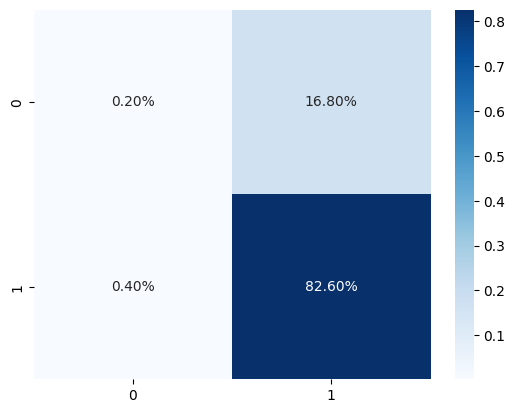

In [256]:
from sklearn.metrics import confusion_matrix

cf_matrix = confusion_matrix(y_test, y_pred)
import seaborn as sns
sns.heatmap(cf_matrix/np.sum(cf_matrix), annot=True,
            fmt='.2%', cmap='Blues')

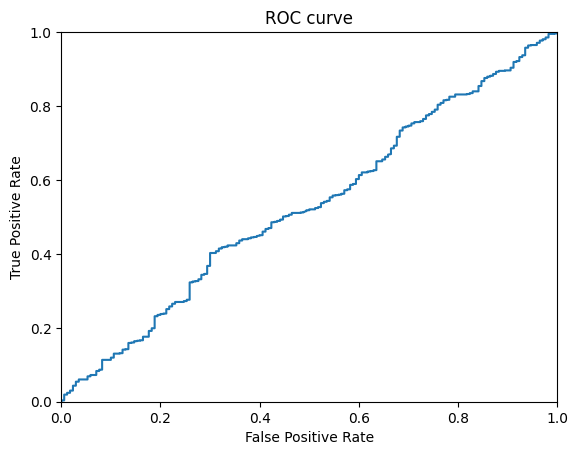

In [257]:
# ROC curve
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
plt.plot(fpr, tpr)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC curve')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.show()
